# Credit Risk Prediction – Model Development

## Objective

The objective of this notebook is to develop and evaluate machine
learning models for loan default prediction using the Home Credit
dataset.

Two classification approaches are compared:

- Logistic Regression as a baseline model.
- XGBoost as a non-linear tree-based model.

Because the target variable is highly imbalanced, model performance is
evaluated using ROC-AUC, PR-AUC, Precision, Recall, and F1-score rather
than accuracy alone.

The exploratory analysis of the dataset is presented in
`01_EDA.ipynb`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

from xgboost import XGBClassifier

import joblib

In [35]:
# Directory used to store project figures.
figures_dir = Path("../figures")
figures_dir.mkdir(parents=True, exist_ok=True)

# Directory used to store locally generated model artifacts.
models_dir = Path("../models")
models_dir.mkdir(parents=True, exist_ok=True)

In [36]:
# Load the Home Credit training dataset.
df = pd.read_csv("application_train.csv")

print("Dataset shape:", df.shape)

Dataset shape: (307511, 122)


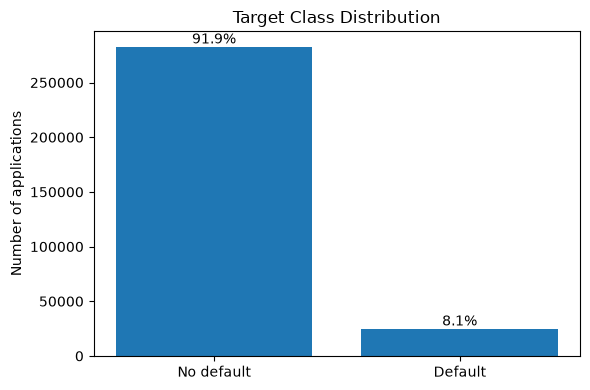

In [4]:
#Let's visualize the target
target_counts = df["TARGET"].value_counts()

plt.figure(figsize=(6, 4))

plt.bar(
    ["No default", "Default"],
    target_counts.values
)

plt.title("Target Class Distribution")
plt.ylabel("Number of applications")

plt.tight_layout()

total = target_counts.sum()

for i, value in enumerate(target_counts.values):
    percentage = value / total * 100

    plt.text(
        i,
        value,
        f"{percentage:.1f}%",
        ha="center",
        va="bottom"
    )

plt.show()

## Train/Validation split

In [5]:
X = df.drop(columns="TARGET")
y = df["TARGET"]

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Validation set:", X_valid.shape)

Training set: (246008, 121)
Validation set: (61503, 121)


## Preprocessing

The dataset contains both numerical and categorical variables, as well
as missing values.

Different preprocessing strategies are therefore applied to each type
of feature:

- Numerical variables:
  - Missing values are replaced using the median.
  - Features are standardized using `StandardScaler`.

- Categorical variables:
  - Missing values are replaced using the most frequent category.
  - Categories are converted into numerical features using one-hot
    encoding.

The same preprocessing pipeline is fitted on the training data and
then applied to the validation data to avoid data leakage.

In [6]:
#Reprocesing
numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_features = X_train.select_dtypes(
    include=["object"]
).columns

print(f"Numeric features: {len(numeric_features)}")
print(f"Categorical features: {len(categorical_features)}")

Numeric features: 105
Categorical features: 16


### Numerical Features

For numerical variables, missing values are replaced with the median
of each feature.

Median imputation is used because several financial variables have
skewed distributions and potential extreme values, as observed during
the exploratory analysis.

After imputation, numerical features are standardized so that they have
a comparable scale. This is particularly relevant for Logistic
Regression.

In [37]:
# Preprocessing pipeline for numerical features.

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

### Categorical Features

Categorical variables are first imputed using their most frequent
category.

They are then converted into binary indicator variables using
one-hot encoding.

`handle_unknown="ignore"` ensures that a category appearing in the
validation data but not observed during training does not cause an
error during transformation.

In [38]:
# Preprocessing pipeline for categorical features.

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=True
    ))
])

### Combined Preprocessing Pipeline

The numerical and categorical transformations are combined using a
`ColumnTransformer`.

This allows each group of variables to receive its appropriate
preprocessing while keeping the resulting dataset in a single feature
matrix.

In [39]:
# Combine numerical and categorical preprocessing.

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

### Fit and Transform the Data

The preprocessing pipeline is fitted using the training data only.
The fitted transformations are then applied to both the training and
validation sets.

This prevents information from the validation set from being used
during preprocessing and helps avoid data leakage.

In [40]:
# Fit the preprocessing pipeline on the training data
# and transform both training and validation sets.

X_train_processed = preprocessor.fit_transform(X_train)
X_valid_processed = preprocessor.transform(X_valid)

print("Original training shape:", X_train.shape)
print("Processed training shape:", X_train_processed.shape)

print("\nOriginal validation shape:", X_valid.shape)
print("Processed validation shape:", X_valid_processed.shape)

Original training shape: (246008, 121)
Processed training shape: (246008, 245)

Original validation shape: (61503, 121)
Processed validation shape: (61503, 245)


## Baseline Model – Logistic Regression

Logistic Regression is used as a baseline classification model.

Because the target variable is highly imbalanced, `class_weight="balanced"`
is used to assign greater importance to the minority class during training.

The model is trained using the preprocessed training data and evaluated
on the validation set.

In [41]:
# Initialize the Logistic Regression baseline model.

logistic_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

In [42]:
# Train the baseline model.

logistic_model.fit(X_train_processed, y_train)

C:\Users\uriel\anaconda3\envs\credit-risk\Lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [43]:
# Generate predictions and predicted probabilities.

y_pred_logistic = logistic_model.predict(X_valid_processed)
y_prob_logistic = logistic_model.predict_proba(X_valid_processed)[:, 1]

### Logistic Regression Evaluation

The Logistic Regression model is evaluated using ROC-AUC, PR-AUC,
Precision, Recall, and F1-score.

These metrics provide a more informative evaluation than accuracy
because the target variable is highly imbalanced.

In [44]:
# Calculate evaluation metrics for Logistic Regression.

logistic_roc_auc = roc_auc_score(y_valid, y_prob_logistic)
logistic_pr_auc = average_precision_score(y_valid, y_prob_logistic)
logistic_precision = precision_score(y_valid, y_pred_logistic)
logistic_recall = recall_score(y_valid, y_pred_logistic)
logistic_f1 = f1_score(y_valid, y_pred_logistic)

print(f"ROC-AUC:   {logistic_roc_auc:.6f}")
print(f"PR-AUC:    {logistic_pr_auc:.6f}")
print(f"Precision: {logistic_precision:.6f}")
print(f"Recall:    {logistic_recall:.6f}")
print(f"F1-score:  {logistic_f1:.6f}")

ROC-AUC:   0.748686
PR-AUC:    0.227942
Precision: 0.161738
Recall:    0.678550
F1-score:  0.261213


### Model Performance Summary

The evaluation metrics are stored in a summary table so that the
baseline model can later be compared with XGBoost.

In [45]:
# Store Logistic Regression results for later model comparison.

results = pd.DataFrame({
    "Model": ["Logistic Regression"],
    "ROC-AUC": [logistic_roc_auc],
    "PR-AUC": [logistic_pr_auc],
    "Precision": [logistic_precision],
    "Recall": [logistic_recall],
    "F1": [logistic_f1]
})

results

,Model,ROC-AUC,PR-AUC,Precision,Recall,F1
0,Logistic Regression,0.748686,0.227942,0.161738,0.67855,0.261213


## XGBoost Model

XGBoost is used as a non-linear tree-based model.

Unlike Logistic Regression, XGBoost can capture non-linear relationships
and interactions between features that may not be represented by a
linear model.

The model is trained using the same preprocessed training and validation
datasets used for the baseline model.

In [12]:
# For XGBoost I use the transformed representation for the
# same preprocessor.
# This allows us to know how much our dataset grew after One-Hot Encoding.
X_train_processed = preprocessor.fit_transform(X_train)
X_valid_processed = preprocessor.transform(X_valid)

print(X_train_processed.shape)

(246008, 245)


In [13]:
#XGBoost

xgb_model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="auc",
    random_state=42,
    n_jobs=-1
)

### Training starts and prediction is coming

In [14]:
#Training
xgb_model.fit(
    X_train_processed,
    y_train,
    eval_set=[
        (X_valid_processed, y_valid)
    ],
    verbose=False
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=-1,
              num_parallel_tree=None, random_state=42, ...)

In [15]:
#Predictions

y_prob_xgb = xgb_model.predict_proba(
    X_valid_processed
)[:, 1]

y_pred_xgb = (
    y_prob_xgb >= 0.5
).astype(int)

xgb_metrics = evaluate_model(
    y_valid,
    y_pred_xgb,
    y_prob_xgb
)

xgb_metrics

{'ROC-AUC': 0.761647409684481,
 'PR-AUC': 0.25555039040948313,
 'Precision': 0.5792079207920792,
 'Recall': 0.023564954682779457,
 'F1': 0.04528740081285079}

### Let's compare with an important table

In [16]:
results = pd.DataFrame(
    [baseline_metrics, xgb_metrics],
    index=["Logistic Regression", "XGBoost"]
)

results.round(4)

,ROC-AUC,PR-AUC,Precision,Recall,F1
Logistic Regression,0.7487,0.2280,0.1618,0.6790,0.2613
XGBoost,0.7616,0.2556,0.5792,0.0236,0.0453


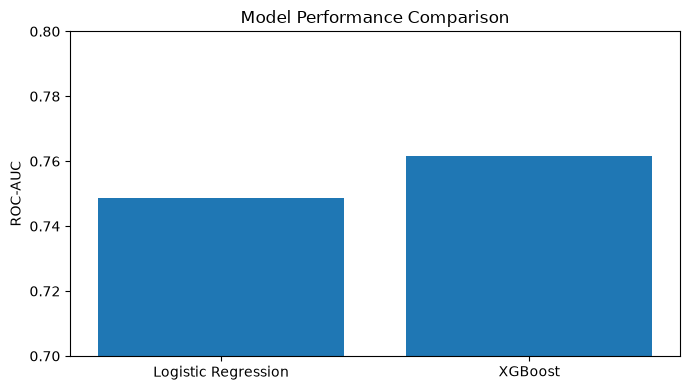

In [27]:
# I prefer to viualize it

plt.figure(figsize=(7, 4))

plt.bar(
    results.index,
    results["ROC-AUC"]
)

plt.ylabel("ROC-AUC")
plt.title("Model Performance Comparison")

plt.ylim(0.7, 0.8)

plt.tight_layout()
plt.show()

### ROC Curve (ROC= Receiver Operating Characteristic)

<Figure size 700x500 with 0 Axes>

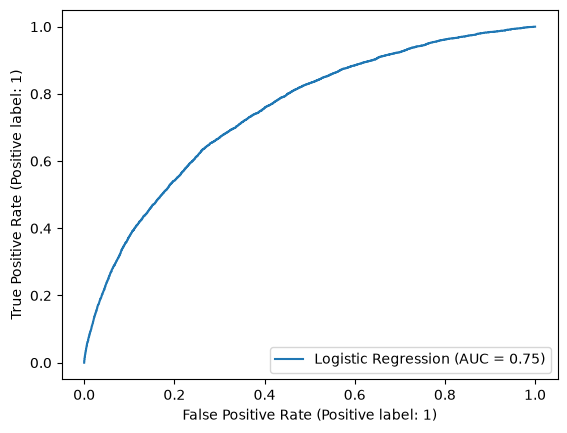

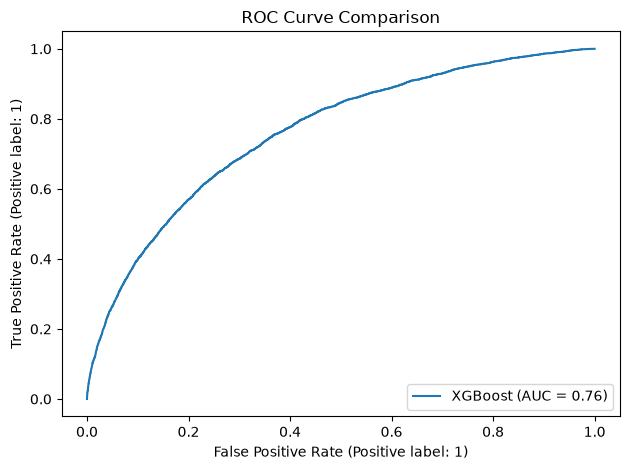

In [18]:
#ROC Curve
plt.figure(figsize=(7, 5))

RocCurveDisplay.from_predictions(
    y_valid,
    y_prob_baseline,
    name="Logistic Regression"
)

RocCurveDisplay.from_predictions(
    y_valid,
    y_prob_xgb,
    name="XGBoost"
)

plt.title("ROC Curve Comparison")
plt.tight_layout()
plt.show()

### Precision - Recall Curve

<Figure size 700x500 with 0 Axes>

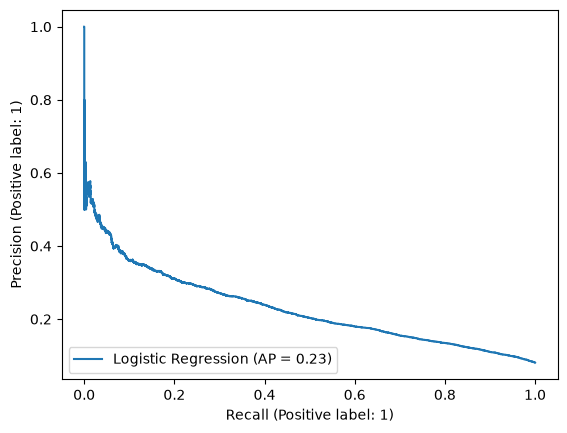

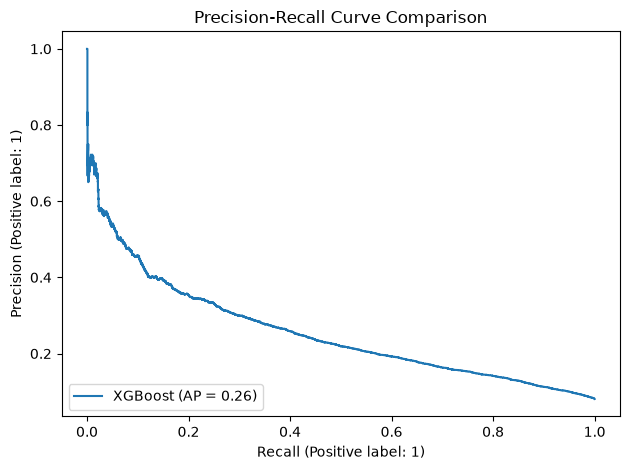

In [19]:
#Due to the significant imbalance at Home Credit, this visualization is also important:

plt.figure(figsize=(7, 5))

PrecisionRecallDisplay.from_predictions(
    y_valid,
    y_prob_baseline,
    name="Logistic Regression"
)

PrecisionRecallDisplay.from_predictions(
    y_valid,
    y_prob_xgb,
    name="XGBoost"
)

plt.title("Precision-Recall Curve Comparison")
plt.tight_layout()
plt.show()

## XGBoost – Confusion Matrix

The confusion matrix provides a detailed view of the classification
results at the default probability threshold of 0.50.

It shows the number of true negatives, false positives, false
negatives, and true positives predicted by the XGBoost model on the
validation set.

Because the dataset is highly imbalanced, the confusion matrix also
helps illustrate the trade-off between correctly identifying default
cases and avoiding false positive predictions.

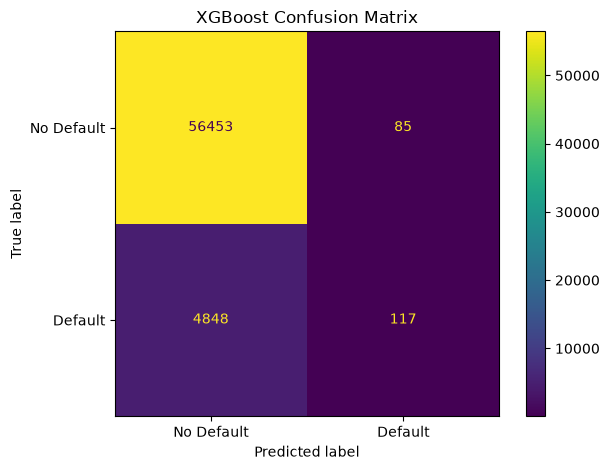

In [46]:
# Display the confusion matrix for XGBoost.

cm = confusion_matrix(y_valid, y_pred_xgb)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Default", "Default"]
)

disp.plot()
plt.title("XGBoost Confusion Matrix")
plt.tight_layout()
plt.savefig(
    figures_dir / "xgb_confusion_matrix.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()

In [24]:
# I save the model, so I won't need to train it again
from pathlib import Path

models_dir = Path("../models")
models_dir.mkdir(parents=True, exist_ok=True)

import joblib

joblib.dump(
    xgb_model,
    models_dir / "xgboost_model.joblib"
)

joblib.dump(
    preprocessor,
    models_dir / "preprocessor.joblib"
)

print("Model and preprocessor saved successfully.")

Model and preprocessor saved successfully.


In [23]:
results

,ROC-AUC,PR-AUC,Precision,Recall,F1
Logistic Regression,0.748685,0.227951,0.161811,0.678953,0.261338
XGBoost,0.761647,0.255550,0.579208,0.023565,0.045287


In [25]:
feature_names = preprocessor.get_feature_names_out()

print("Number of transformed features:", len(feature_names))

Number of transformed features: 245


## Threshold Analysis

For binary classification, the model produces a probability of default
rather than a final yes/no decision.

The default classification threshold is 0.5, but this threshold may not
be appropriate for an imbalanced credit-risk problem.

We therefore evaluate different probability thresholds to understand
the trade-off between:

- Precision: proportion of predicted defaults that are actual defaults.
- Recall: proportion of actual defaults detected by the model.
- F1-score: harmonic mean of Precision and Recall.

This analysis helps identify a threshold that better reflects the
business objective.

In [28]:
from sklearn.metrics import precision_recall_curve

# Evaluate different classification thresholds
thresholds = np.arange(0.10, 0.51, 0.05)

threshold_results = []

for threshold in thresholds:
    y_pred_threshold = (y_prob_xgb >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_valid, y_pred_threshold),
        "Recall": recall_score(y_valid, y_pred_threshold),
        "F1": f1_score(y_valid, y_pred_threshold)
    })

threshold_results = pd.DataFrame(threshold_results)

threshold_results

,Threshold,Precision,Recall,F1
0,0.10,0.192524,0.598590,0.291344
1,0.15,0.246944,0.427190,0.312970
2,0.20,0.298880,0.301108,0.299990
3,0.25,0.346141,0.208661,0.260367
4,0.30,0.396868,0.148036,0.215637
5,0.35,0.452529,0.102719,0.167433
6,0.40,0.505360,0.066465,0.117480
7,0.45,0.558583,0.041289,0.076894
8,0.50,0.579208,0.023565,0.045287


### Precision–Recall Trade-off

Changing the classification threshold produces a trade-off between
Precision and Recall.

Lower thresholds identify more potential defaults, increasing Recall
but also increasing the number of false positives.

Higher thresholds produce more precise positive predictions, but fewer
actual defaults are detected.

The F1-score provides a balanced metric between Precision and Recall
and reaches its maximum among the evaluated thresholds at 0.15.

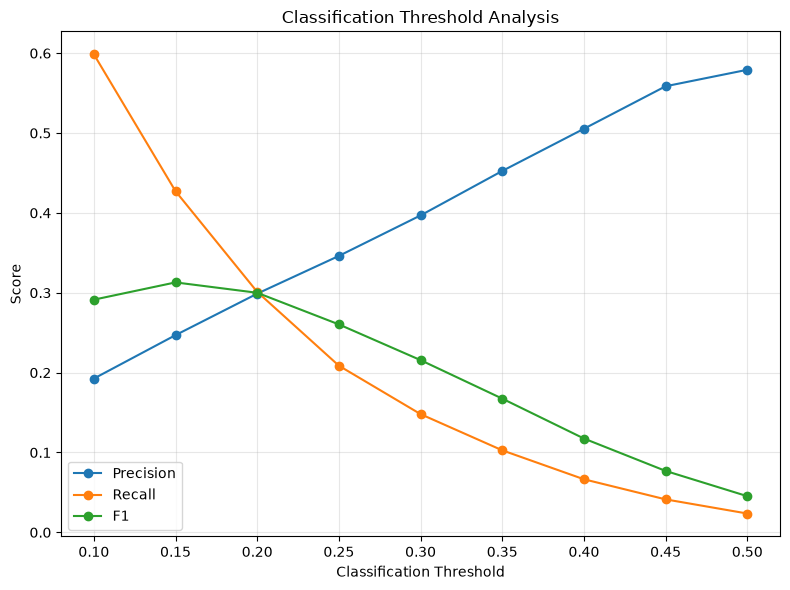

In [31]:
from pathlib import Path
figures_dir = Path("../figures")
figures_dir.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(8, 6))

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["F1"],
    marker="o",
    label="F1"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Classification Threshold Analysis")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

# Save the figure for the GitHub project
plt.savefig(
    figures_dir / "threshold_analysis.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Saving the Final Model

The trained XGBoost model and preprocessing pipeline are saved locally
so that the model can be reused in the model interpretation stage.

The saved artifacts correspond to the software environment used during
training, ensuring consistency between model development and SHAP analysis.

In [32]:
from pathlib import Path
import joblib

# Create the models directory if it does not exist
models_dir = Path("../models")
models_dir.mkdir(parents=True, exist_ok=True)

# Save the trained XGBoost model
joblib.dump(
    xgb_model,
    models_dir / "xgboost_model.joblib"
)

# Save the fitted preprocessing pipeline
joblib.dump(
    preprocessor,
    models_dir / "preprocessor.joblib"
)

print("Model and preprocessor saved successfully.")

Model and preprocessor saved successfully.


## Conclusions

Two classification models were developed and evaluated for loan default
prediction: Logistic Regression and XGBoost.

Logistic Regression achieved a ROC-AUC of 0.7487 and a PR-AUC of
0.2280, providing a useful baseline for the classification task.

XGBoost achieved a ROC-AUC of 0.7616 and a PR-AUC of 0.2556, indicating
that the non-linear model captured additional predictive patterns in
the data.

At the default probability threshold of 0.50, XGBoost achieved a
precision of 0.5792, recall of 0.0236, and F1-score of 0.0453. The low
recall at this threshold highlights the effect of class imbalance and
the importance of selecting an appropriate decision threshold.

A threshold analysis showed that, among the tested thresholds, 0.15
produced the highest F1-score of 0.3130, with a precision of 0.2469 and
a recall of 0.4272.

The threshold should not be interpreted as universally optimal. Its
selection depends on the relative costs of false positives and false
negatives in the intended credit-risk application.

## Limitations and Next Steps

Several limitations should be considered when interpreting these
results.

- The target variable is strongly imbalanced, which affects the
  precision and recall trade-off.
- The selected probability threshold was evaluated using a limited set
  of candidate values and should be validated according to the
  requirements of a real-world application.
- The model performance was evaluated using a single train-validation
  split.
- The current analysis focuses on predictive performance and does not
  establish causal relationships between features and loan default.
- Additional model validation, calibration, and fairness analysis would
  be required before considering deployment in a real credit decision
  system.

The next stage of the project focuses on interpreting the XGBoost model
using SHAP values in order to understand which features contribute most
strongly to its predictions.

## Project Summary

The modeling stage established an XGBoost-based approach for predicting
loan default in the Home Credit dataset.

The final model achieved a ROC-AUC of 0.7616 and a PR-AUC of 0.2556 on
the validation set. Threshold analysis demonstrated that changing the
decision threshold substantially affects the balance between precision
and recall.

The trained XGBoost model and preprocessing pipeline are saved as
reusable artifacts for the model interpretation stage.

The next notebook, `03_SHAP_Interpretation.ipynb`, uses SHAP to examine
global feature importance, individual predictions, and the direction
of feature contributions.